# PyTorch Tutorial

## 1. Tensors

Tensors are a data structure similar to arrays and matrices.

__In PyTorch, tensors encode the inputs and outputs of a model, as well as the model's parameters.__

Tensors are similar to NumPy's ndarrays, except that tensors can run on GPUs (/hardware accelerators).

Tensors and NumPy arrays can often share the same underlying memory, removing the need to copy data.

Tensors are also optimised for __automatic differentiation__ (Autograd).

In [1]:
import torch
import numpy as np

### Initializing a Tensor

Tensors can be initialized in various ways:

__Directly from data__:

In [2]:
data = [[1, 2], [3, 4]]
x_data = torch.tensor(data)

__From a NumPy array__:

In [3]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

__From another tensor__:

In [4]:
# retains the properties of x_data:
x_ones = torch.ones_like(x_data)
print(f"Ones Tensor: \n {x_ones} \n")

# overrides the datatype of x_data:
x_rand = torch.rand_like(x_data, dtype = torch.float)
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.3033, 0.4268],
        [0.2614, 0.6916]]) 



__With random or constant values__:

'shape' is a tuple of tensor dimensions. In the functions below, it determines the dimensionality of the output tensor.

In [5]:
shape = (2, 3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor} \n")

Random Tensor: 
 tensor([[0.5363, 0.5247, 0.9540],
        [0.2635, 0.2154, 0.4310]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]]) 



### Attributes of a Tensor

Tensor attributes describe their shape, datatype, and the device on which they are stored.

In [6]:
tensor = torch.rand(3, 4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


### Operations on Tensors

There are over 1200 tensor operations, including arithmetic, linear algebra, matrix manipulation, and more.

Each of these operations can be run on the CPU, or an Accelerator such as CUDA.

By default, tensors are created on the CPU.

We need to explicitly move tensors to the accelerator using .to method, __after checking for accelerator availability__.

In [7]:
# Moving the tensor to the current accelerator, if available
if torch.accelerator.is_available():
    tensor = tensor.to(torch.accelerator.current_accelerator())

__Standard numpy-like indexing and slicing__:

In [8]:
tensor = torch.ones(4, 4)
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[..., -1]}")
tensor[:,1] = 0
print(tensor)

First row: tensor([1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1.])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


__Joining tensors__

You can use torch.cat to concatenate a sequence of tensors along a given dimension.

There is also torch.stack

In [9]:
t1 = torch.cat([tensor, tensor, tensor], dim = 1)
print(t1)

tensor([[1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.]])


__Arithmetic operations__

In [10]:
# Computing the matrix multiplication between two tensors.
# y1, y2, y3, will have the same value.
# 'tensor.T' returns the transpose of a tensor
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)

y3 = torch.rand_like(y1)
torch.matmul(tensor, tensor.T, out = y3)

# The code above is 3 different ways to multiply tensors ^^^

# Computing the element-wise product.
# z1, z2, z3, will have the same value
z1 = tensor * tensor
z2 = tensor.mul(tensor)

z3 = torch.rand_like(tensor)
torch.mul(tensor, tensor, out = z3)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

__Single-element tensors__ - if you have a one-element tensor, for example by aggregating all values of a tensor into one value, you can convert it to a Python numerical value using item()

In [11]:
agg = tensor.sum()
agg_item = agg.item()
print(agg_item, type(agg_item))

12.0 <class 'float'>


__In-place operations__ - operations that store the result into the operand are called in-place.

They are denoted by a '_' suffix.

For example: x.copy_(y), x.t_() will change x.

In [12]:
print(f"{tensor} \n")
tensor.add_(5)
print(tensor)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]]) 

tensor([[6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.]])


In-place operations save memory but cause problems when computing derivatives due to the immediate loss of memory. Their use is discouraged.

### Bridge with NumPy

Tensors on the CPU and NumPy arrays can share their underlying memory locations, and changing one will change the other.

### Tensor to NumPy array

In [13]:
t = torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")

t: tensor([1., 1., 1., 1., 1.])
n: [1. 1. 1. 1. 1.]


A change in the tensor can be seen in the NumPy array

In [14]:
t.add_(1)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.])
n: [2. 2. 2. 2. 2.]


### NumPy array to Tensor

In [15]:
n = np.ones(5)
t = torch.from_numpy(n)

Changes in the NumPy array show changes in the tensor

In [16]:
np.add(n, 1, out = n)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.], dtype=torch.float64)
n: [2. 2. 2. 2. 2.]


## Datasets & DataLoaders

As code for processing data samples can get messy, PyTorch separates dataset code from model training code.

PyTorch provides two data primitives: `torch.utils.data.DataLoader` and `torch.utils.data.Dataset`, that allow you to use pre-loaded datasets as well as your own data.

`Dataset` stores the samples and labels, and `DataLoader` wraps an iterable around the `Dataset` to enable easy access of the samples.

PyTorch domain libraries have a number of pre-loaded datasets, such as FashionMNIST, that subclass `torch.utils.data.Dataset` and implement functions specific to that data.

They can be used to prototype and benchmark your model.

### Loading a Dataset

This example will load the FashionMNIST dataset from TorchVision. It consists of 60,000 training examples and 10,000 test examples. Each example is a 28x28 grayscale image and an associated label from one of 10 classes.

We can load the FashionMNIST Dataset with the following parameters:
- `root` is the path where the train/test data is stored
- `train` specifies training or test dataset
- `download=True` downloads the data from the internet if it's not available at `root`
- `transform` and `target_transform` specify the feature and label transformations

In [17]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 344kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.24MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 7.18MB/s]


### Iterating and Visualising the Dataset

We can index `Datasets` manually like a list: `training_data[index]`. We use `matplotlib` to visualise some samples in our training data.

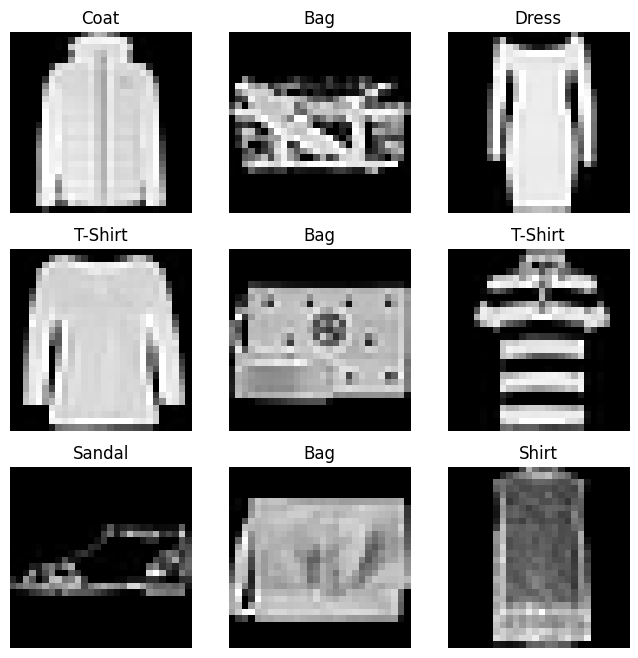

In [18]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize=(8,8))
cols, rows = 3, 3

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

### Creating a Custom Dataset for your files

A custom Dataset class must implement three functions: `__init__`, `__len__`, and `__getitem__`.

In this implementation, the FashionMNIST images are stored in a directory `img_dir`, and their labels are stored separately in a CSV file `annotations_file`.

In [25]:
import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
  def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
    self.img_labels = pd.read_csv(annotations_file)
    self.img_dir = img_dir
    self.transform = transform
    self.target_transform = target_transform

def __len__(self):
  return len(self.img_labels)

def __getitem__(self, idx):
  img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
  image = decode_image(img_path)
  label = self.img_labels.iloc[idx, 1]
  if self.transform:
    image = self.transform(image)
  if self.target_transform:
    label = self.target_transform(label)
  return image, label

## Quickstart

### Working with data

PyTorch has two primitives to work with data:

- torch.utils.data.DataLoader
- torch.utils.data.Dataset

'Dataset' stores the samples and their corresponding labels, and 'DataLoader' wraps an iterable around the 'Dataset'.

In [19]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

PyTorch has domain-specific libraries like TorchText, TorchVision, and TorchAudio, and they all include datasets.

This tutorial will use a TorchVision dataset.

The torchvision.datasets module contains Dataset objects for many real-world vision data.

Tutorial will use the FashionMNIST dataset.

Every TorchVision Dataset includes two arguments:
- transform
- target_transform

To modify the samples and labels respectively.

In [20]:
# Downloading training data from open datasets
training_data = datasets.FashionMNIST(
    root = "data",
    train = True,
    download = True,
    transform = ToTensor(),
)

# Downloading test data from open datasets
test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor(),
)

We pass the Dataset as an argument to DataLoader.

This wraps an iterable over our dataset, and supports automatic batching, sampling, shuffling, and multiprocess data loading.

Here we will define a batch size of 64; each element in the dataloader iterable will return a batch of 64 features and labels

In [21]:
batch_size = 64

# Creating data loaders
train_dataloader = DataLoader(training_data, batch_size = batch_size)
test_dataloader = DataLoader(test_data, batch_size = batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


### Creating Models

To define a neural network in PyTorch, we create a class that inherits from nn.Module.

We define the layers of the network in the '\_\_init__' function and specify how data will pass through the network in the 'forward' function.

To accelerate operations in the neural network, we move it to the accelerator, such as CUDA or XPU. If the current accelerator is available, we use it. Otherwise, we use the CPU.

In [22]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Defining model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

Using cpu device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


### Optimizing the Model Parameters

To train a model, we need a loss function and an optimizer

In [23]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 1e-3)

In a single training loop, the model makes predictions on the training dataset - fed to it in batches - and then backpropagates the prediction error to adjust the model's parameters.

In [24]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Computing prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")